# Anomaly Detection

This notebook begins the first detection stage that goes beyond descriptive monitoring and into transaction-level alert scoring.

The earlier notebooks established three important foundations for this project. First, the raw PaySim dataset was audited for structure and data quality. Second, the exploratory monitoring phase identified where fraud concentrates, how it changes over time, and why transaction type and behavioral context matter. Third, the feature engineering phase translated those patterns into reusable historical features that rely only on information available before each transaction occurs.

The goal of this notebook is to use those engineered features in an unsupervised anomaly-detection workflow. This is valuable because anomaly detection answers a different question than a supervised classifier. Instead of asking whether a transaction looks like known fraud based on labels alone, it asks whether the transaction behaves unusually relative to the broader system.

To keep the analysis honest, the reusable anomaly pipeline now fits the isolation forest on earlier transactions and evaluates ranked alerts on a later holdout period. That makes the results a simple out-of-time backtest rather than an in-sample score summary.


## 1. Preparing the notebook environment

This first step sets up the notebook so it can be executed from either the project root or the `notebooks/` directory without breaking imports.

The cell imports the core analytical libraries used in this notebook, enables wider dataframe display, and ensures the project root is available on Python's import path. This keeps the notebook portable and consistent with the modular source-code structure used across the rest of the project.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Defining the processed-data and output paths

This notebook depends on the engineered feature dataset produced in the previous phase. It also creates a dedicated output folder for anomaly-detection artifacts so that the ranked alerts and summary tables can be reused later in the business-summary notebook.

Keeping these paths explicit is an important large-dataset workflow practice. It prevents accidental path drift, avoids hard-coded absolute machine-specific references, and makes the notebook easier to rerun in a clean environment.


In [2]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_5_anomaly_detection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATA_PROCESSED / "model_features.parquet"

print("Feature dataset exists:", FEATURES_PATH.exists())
print("Output directory:", OUTPUT_DIR)


Feature dataset exists: True
Output directory: /Users/twon/Documents/Time Series Analysis Project/data/outputs/phase_5_anomaly_detection


## 3. Importing the reusable anomaly-detection functions

Rather than writing model logic directly inside the notebook, this phase imports reusable functions from `src.anomaly` and `src.feature_engineering`.

This design keeps the notebook readable and lets the source code carry the heavier implementation details. That separation is especially useful in portfolio work because it shows both sides of the project clearly: the notebook communicates the analytical story, while the source modules provide the scalable implementation.


In [3]:
from src.anomaly import (
    get_anomaly_feature_columns,
    run_anomaly_detection,
)
from src.feature_engineering import build_model_features


## 4. Loading the engineered feature dataset

The preferred input for this notebook is the parquet file saved by the feature-engineering phase. If that file is missing, the notebook rebuilds the feature dataset directly from the raw CSV so the workflow remains self-contained.

This fallback is helpful for reproducibility. It means the project can still be run end to end even if the intermediate parquet artifact is absent.


In [4]:
if FEATURES_PATH.exists():
    df = pd.read_parquet(FEATURES_PATH)
else:
    raw_path = PROJECT_ROOT / "data" / "raw" / "paysim dataset.csv"
    df = build_model_features(pd.read_csv(raw_path))

print("Feature dataset shape:", df.shape)
df.head()


Feature dataset shape: (6362620, 38)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,row_id,hour,day,is_transfer,is_cash_out,orig_txn_count_prior,orig_amount_prior_sum,orig_avg_amount_prior,orig_prev_step,orig_time_since_prev,orig_prev_amount,orig_amount_to_oldbalance_ratio,orig_balance_drop,orig_balance_drop_ratio,orig_amount_vs_prior_avg,dest_txn_count_prior,dest_amount_prior_sum,dest_avg_amount_prior,dest_prev_step,dest_time_since_prev,amount_vs_dest_prior_avg,orig_txn_count_last_1,orig_amount_sum_last_1,orig_txn_count_last_6,orig_amount_sum_last_6,orig_txn_count_last_24,orig_amount_sum_last_24
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0,0,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.0578,"9,839.6400",0.0578,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0,1,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.0877,"1,864.2800",0.0877,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0,2,1,0,1,0,0,0.0000,NaN,NaN,NaN,NaN,1.0000,181.0000,1.0000,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0,3,1,0,0,1,0,0.0000,NaN,NaN,NaN,NaN,1.0000,181.0000,1.0000,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0,4,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.2808,"11,668.1400",0.2808,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Selecting the anomaly-detection feature set

Anomaly detection should focus on numeric variables that represent transaction size, balance context, temporal position, and historical behavior.

The helper function used here automatically selects the engineered columns that are actually present in the dataset. That small design choice improves robustness because the notebook will not fail simply because a future feature-building pass drops or renames a column.


In [5]:
anomaly_feature_columns = get_anomaly_feature_columns(df)

print("Number of anomaly features:", len(anomaly_feature_columns))
anomaly_feature_columns


Number of anomaly features: 32


['step',
 'hour',
 'day',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'is_transfer',
 'is_cash_out',
 'orig_txn_count_prior',
 'orig_amount_prior_sum',
 'orig_avg_amount_prior',
 'orig_prev_step',
 'orig_time_since_prev',
 'orig_prev_amount',
 'orig_amount_to_oldbalance_ratio',
 'orig_balance_drop',
 'orig_balance_drop_ratio',
 'orig_amount_vs_prior_avg',
 'dest_txn_count_prior',
 'dest_amount_prior_sum',
 'dest_avg_amount_prior',
 'dest_prev_step',
 'dest_time_since_prev',
 'amount_vs_dest_prior_avg',
 'orig_txn_count_last_1',
 'orig_amount_sum_last_1',
 'orig_txn_count_last_6',
 'orig_amount_sum_last_6',
 'orig_txn_count_last_24',
 'orig_amount_sum_last_24']

## 6. Running the isolation-forest anomaly pipeline

This step fits an unsupervised isolation forest on earlier periods of the engineered feature table and then scores a later holdout period.

The pipeline produces four reusable outputs:

- a split summary showing which rows were used for fitting and which rows were reserved for evaluation
- a top-k summary showing how much observed fraud appears among the highest-ranked alerts in the holdout window
- a decile summary showing how fraud concentration changes as anomaly score increases
- a ranked alert table that can be inspected directly

The point is not to claim that anomaly detection replaces supervised modeling. The point is to test whether an unsupervised alerting layer can meaningfully concentrate fraud near the top of the queue on future data.


In [6]:
anomaly_outputs = run_anomaly_detection(df, feature_columns=anomaly_feature_columns)

list(anomaly_outputs)


['anomaly_split_summary',
 'anomaly_topk_summary',
 'anomaly_decile_summary',
 'anomaly_top_alerts']

## 7. Reviewing the anomaly fit and evaluation split

Before interpreting the alert metrics, it is important to confirm the temporal backtest structure.

This table shows how many rows were used to fit the unsupervised model and how many rows were reserved for later evaluation. That framing matters because anomaly-detection results are much more credible when they are evaluated on a future holdout period instead of on the same rows used for fitting.


In [7]:
anomaly_outputs["anomaly_split_summary"]


,split,row_count,fraud_count,min_step,max_step
0,fit,6273162,6969,1,632
1,test,89458,1244,633,743


## 8. Reviewing precision-at-k behavior

This summary is one of the most operationally important outputs in the notebook.

Fraud teams rarely review millions of transactions one by one. Instead, they review a manageable alert queue. For that reason, the most useful early question is not just whether the anomaly scores exist, but whether the top-ranked alerts contain fraud at a meaningfully higher rate than the full dataset baseline.


In [8]:
anomaly_outputs["anomaly_topk_summary"]


,top_k,fraud_hits,precision_at_k,recall_at_k
0,100,5,0.0500,0.0040
1,500,39,0.0780,0.0314
2,1000,62,0.0620,0.0498
3,5000,229,0.0458,0.1841


## 9. Reviewing anomaly-score segments

The decile summary shows whether fraud concentration rises as transactions become more anomalous.

If the highest-score segments contain a much larger fraud share than the lower-score segments, that is a strong signal that the anomaly model is surfacing useful operational risk even without direct label supervision.


In [9]:
anomaly_outputs["anomaly_decile_summary"]


,alert_decile,txn_count,fraud_count,avg_anomaly_score,avg_amount,fraud_rate
0,D10,8946,339,0.6048,"689,655.6840",0.0379
1,D9,8946,176,0.5507,"320,331.0053",0.0197
2,D8,8946,142,0.5278,"227,268.6702",0.0159
3,D7,8945,116,0.5120,"172,299.5888",0.0130
4,D6,8946,142,0.4985,"135,545.7634",0.0159
5,D5,8946,290,0.4707,"160,013.0137",0.0324
6,D4,8945,39,0.4171,"91,143.9861",0.0044
7,D3,8946,0,0.3989,"12,944.9711",0.0000
8,D2,8946,0,0.3949,"12,593.0148",0.0000
9,D1,8946,0,0.3927,"11,237.2337",0.0000


## 10. Inspecting the highest-ranked anomaly alerts

Aggregate metrics are useful, but direct row-level inspection is still important. This step displays the highest-ranked alerts so the scoring behavior can be interpreted in concrete transaction terms.

In practice, this is where an analyst starts asking whether the model is prioritizing very large transfers, rapid sender bursts, newly activated destinations, or other unusual account behaviors that are plausible fraud signals.


In [10]:
review_columns = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "nameDest",
    "isFraud",
    "anomaly_score",
    "orig_time_since_prev",
    "orig_amount_vs_prior_avg",
    "amount_vs_dest_prior_avg",
]
review_columns = [column for column in review_columns if column in anomaly_outputs["anomaly_top_alerts"].columns]

anomaly_outputs["anomaly_top_alerts"][review_columns].head(20)


,step,type,amount,nameOrig,nameDest,isFraud,anomaly_score,orig_time_since_prev,orig_amount_vs_prior_avg,amount_vs_dest_prior_avg
0,659,CASH_IN,"608,969.0800",C566397402,C753526445,0,0.7492,NaN,NaN,0.0963
1,640,CASH_IN,"501,688.0400",C1155072617,C1347825685,0,0.7486,NaN,NaN,0.1435
2,659,TRANSFER,"4,163,229.8100",C265718030,C1380922009,0,0.7476,NaN,NaN,8.2552
3,681,TRANSFER,"11,368,206.7700",C75141704,C2134893079,0,0.7300,NaN,NaN,10.3254
4,656,TRANSFER,"2,957,675.5400",C1517305057,C489712935,0,0.7292,NaN,NaN,2.2864
5,684,TRANSFER,"6,890,721.6000",C166256917,C1558871905,0,0.7227,NaN,NaN,11.6840
6,705,TRANSFER,"3,259,143.4600",C401040325,C1013369800,0,0.7218,NaN,NaN,1.9798
7,684,TRANSFER,"3,285,375.3200",C1788289365,C1102350206,0,0.7205,NaN,NaN,4.0830
8,659,TRANSFER,"8,648,516.9600",C1435043980,C510491840,0,0.7204,NaN,NaN,2.4559
9,683,TRANSFER,"5,653,928.3500",C1036613601,C1388945976,0,0.7204,NaN,NaN,10.0710


## 11. Visualizing fraud concentration across the anomaly ranking

A simple chart makes the segment pattern easier to read quickly. This is especially useful when the notebook is later reused in stakeholder discussions or portfolio review, because the visual form shows whether anomaly severity and fraud concentration move together.


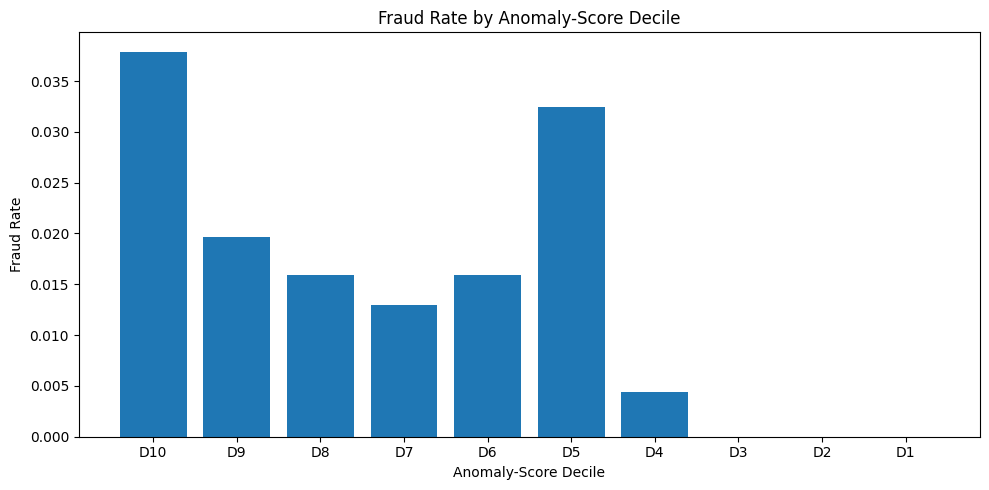

In [11]:
decile_summary = anomaly_outputs["anomaly_decile_summary"].copy()

plt.figure(figsize=(10, 5))
plt.bar(decile_summary["alert_decile"], decile_summary["fraud_rate"])
plt.title("Fraud Rate by Anomaly-Score Decile")
plt.xlabel("Anomaly-Score Decile")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Saving the anomaly outputs for downstream use

The tables produced in this notebook are saved to the project output folder so they can be reused later in the business summary without rerunning the full anomaly pipeline.

Persisting these outputs is good project practice because it separates heavy computation from final reporting and makes the workflow easier to reproduce on demand.


In [12]:
for name, table in anomaly_outputs.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print("Saved anomaly outputs to:", OUTPUT_DIR)


Saved anomaly outputs to: /Users/twon/Documents/Time Series Analysis Project/data/outputs/phase_5_anomaly_detection


## 13. Phase summary

This notebook introduced an unsupervised alerting layer on top of the engineered transaction features.

The main outcome of the phase is not that anomaly detection replaces a supervised fraud model. Instead, it provides a second lens on transaction risk. That lens is valuable because it can surface unusual behavior patterns, create ranked alert queues, and complement later predictive models.

The next notebook moves into supervised modeling, where the project can test whether the engineered historical features improve direct fraud prediction on a time-aware train, validation, and test split.
